# Linear Regression on Odds

This notebook will form three linear regression models (least squares, ridge, LASSO) to predict Djokovic's odds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns
from utils import *

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../Data/full_data_enc.csv")

In [3]:
df.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age_c,age_c_sq,is_outdoor,...,Masters Cup,Clay,Grass,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,417,97,5.00,1170,28,1.14,0,-9.817933,96.391807,1,...,0,1,0,1,0,0,0,0,0,0
1,440,97,3.50,1385,18,1.28,0,-9.765914,95.373072,1,...,0,0,0,0,0,0,0,0,0,0
2,431,97,2.50,825,43,1.50,1,-9.724846,94.572630,1,...,0,0,0,0,0,0,0,0,0,0
3,431,97,3.50,1230,24,1.28,1,-9.716632,94.412946,1,...,0,0,0,1,0,0,0,0,0,0
4,431,97,2.75,770,48,1.39,0,-9.711157,94.306565,1,...,0,0,0,0,1,0,0,0,0,0


## 1. Data Setup

Two potential target variables existed in the original dataset: Odds and win/loss for Djokovic. Win/Loss prediction is a classification task, while we can try and predict the bookmaker odds from our chosen features using classic linear regression. In this sense, we are attempting to predict the bookmaker's odds given our chosen features, and this will give a good indication of whether our features have been used to produce these odds.

We must drop the dj_win column since this information is only available for each match once we know the outcome, and so is not available at the time of the bookmaker odds being produced. Keeping these in the dataframe for the linear regression will result in unwanted data leakage, and if we ever wanted to apply our models to real use cases, we would not have access to this feature. We also need to remove the opponent odds column, since this is inversely related to Djokovic's odds, and would again enforce some leakage.

In [4]:
df = df.copy().drop(columns=['dj_win', 'opp_odds'])

Now we form the prediction variable matrix and the target variable vector.

In [5]:
y = df['dj_odds'].to_numpy()
X = df[df.columns.difference(['dj_odds'])].to_numpy()

We now split our data into a training and test set. We do not shuffle our data since the rows are in chronological order and we want to do a temporal split. This will ensure no temporal leakage from the test set into the training set, and ensure that the models do not learn arbitrary patterns, but actually those that would make them deployable since we would want them to perform best on current matches.

In [6]:
X_train, X_test, y_train, y_test = chrono_split(X, y, 0.8)

Next, we will standardise our data, and add an intercept column. Standardisation ensures stable learning and a common scale for all variables, so no variables are prioritised by the model purely due to their magnitude. Adding an intercept column allows the model to represent the data better.

In [14]:
X_train_std = standardise_cols(X_train, np.arange(0, X_train.shape[1]))
X_test_std = standardise_cols(X_test, np.arange(0, X_test.shape[1]), scaler=X_train)
X_train_aug = np.hstack([np.ones((X_train.shape[0], 1)), X_train_std])
X_test_aug = np.hstack([np.ones((X_test.shape[0], 1)), X_test_std])

## 2. Least Squares Regression

We begin our odds modelling with a classic least squares regression.

In [15]:
# Computing coefficients vector
theta = np.linalg.solve(X_train_aug.T @ X_train_aug, X_train_aug.T @ y_train)

In [16]:
# Calculating mean squared error on train set
y_train_hat = X_train_aug @ theta
mse_train = mse(y_train, y_train_hat)

In [17]:
# Calculating mean squared error on test set
y_test_hat = X_test_aug @ theta
mse_test = mse(y_test, y_test_hat)

In [18]:
print("Mean squared error on train and test set for classic least squares")
print("-"*70)
print(f"Train set: {mse_train}")
print(f"Test set: {mse_test}")

Mean squared error on train and test set for classic least squares
----------------------------------------------------------------------
Train set: 0.33869567818329005
Test set: 0.4380955734804875


## 3. Ridge Regression

Now we will use a ridge regression model. This may improve our mean squared error as ridge introduces a little bias but decreases the variance of the estimators, and of course $mse = bias^2 + variance$. We will use a hyperparameter search to establish the optimal value for $\lambda$, the regularisation parameter. We saw in our EDA notebook that there is some colinearity between vairables, hence ridge regression $\textit{should}$ give us a better mean squared error.

We will first define a cross validation function that will be used in the inner loop of our hyperparameter search. This is cleaner and will make the operations clearer.

In [19]:
def cross_val_loop(X, y, lam, k=5):

    """
        This is a loop for the cross validation used in the hyperparameter
        search for ridge regression. X is the predictor matrix, y is the target
        vector, lam is the hyperparameter lambda, and k is the number of folds.
    """

    val_mses = []

    for j in range(k):
    
        # Making the folds for this cross-validation iteration
        folds = make_folds(X, k)
        val_fold = folds[j]
        train_folds = np.hstack(folds[:j] + folds[j+1:])
    
        X_train_fold = X[train_folds]
        X_val_fold = X[val_fold]
    
        y_train_fold = y[train_folds]
        y_val_fold = y[val_fold]
    
        # Standardising the predictors
        X_train_std = standardise_cols(X_train_fold, np.arange(0, X_train_fold.shape[1]))
        X_val_std = standardise_cols(X_val_fold, np.arange(0, X_val_fold.shape[1]), scaler=X_train_fold)
    
        # Augmenting matrices to add intercept term
        X_train_aug_fold = np.hstack([np.ones((X_train_std.shape[0], 1)), X_train_std])
        X_val_aug_fold = np.hstack([np.ones((X_val_std.shape[0], 1)), X_val_std])
    
        # Get coefficients
        theta_lam = np.linalg.solve(X_train_aug_fold.T @ X_train_aug_fold + lam * penal_id,
                                        X_train_aug_fold.T @ y_train_fold)
    
        # avg val mse
        y_hat_fold = X_val_aug_fold @ theta_lam
        mse_val_r = mse(y_val_fold, y_hat_fold)
        val_mses.append(mse_val_r)

    # Return average mse of all folds
    return np.mean(val_mses)

In [20]:
# Set hyperparameter search grid
resolution = 1000
lambdas = np.logspace(-4, 4, num=resolution)
thetas = np.zeros(resolution)
avg_val_mses = np.zeros(resolution)

# Forming non-intercept penalising matrix
penal_id = np.eye(X.shape[1]+1)
penal_id[0, 0] = 0

# Hyperparameter search
for i, lam in enumerate(lambdas):

    # k-fold validation
    avg_mse = cross_val_loop(X_train, y_train, lam, k=5)

    # Store average validation mse
    avg_val_mses[i] = avg_mse

# Find optimal lam
opt_i = np.argmin(avg_val_mses)
opt_lam = lambdas[opt_i]

print(f"The optimal lambda is: {opt_lam}")


The optimal lambda is: 146.6108684046983


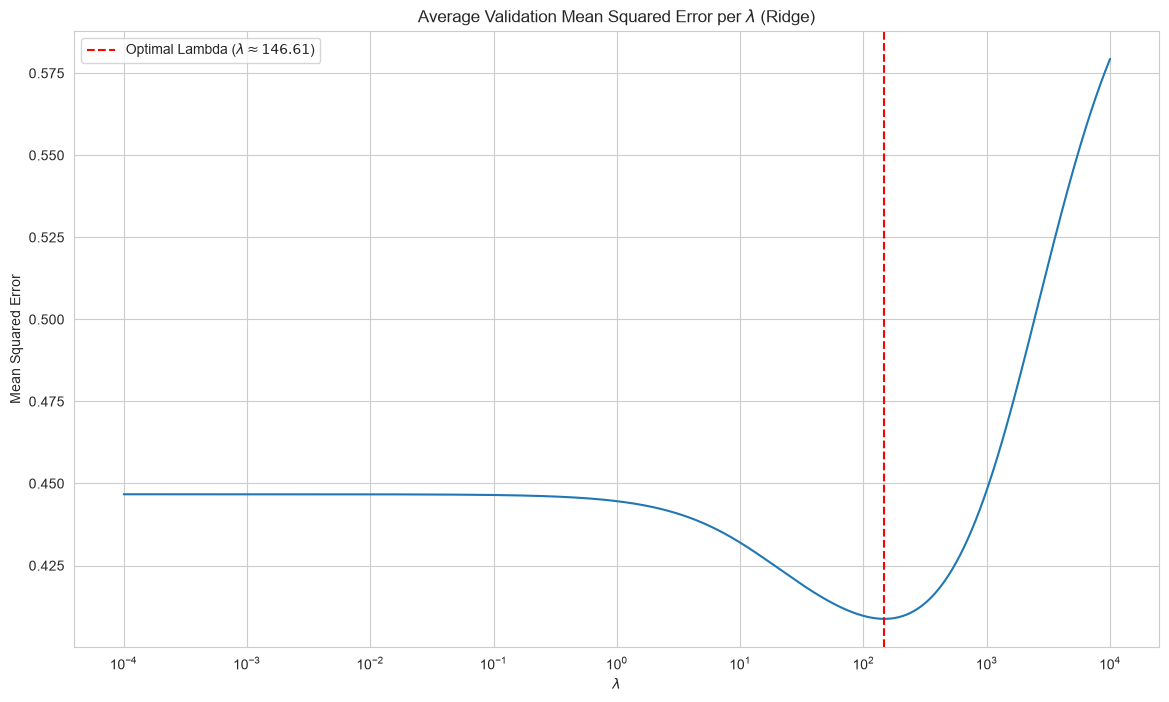

In [21]:
plt.figure(figsize=(14, 8))
plt.plot(lambdas, avg_val_mses)
plt.xscale("log")
plt.axvline(opt_lam, color="red", linestyle="--",
            label=rf"Optimal Lambda ($\lambda \approx {opt_lam:.2f}$)")
plt.title(r"Average Validation Mean Squared Error per $\lambda$ (Ridge)")
plt.ylabel("Mean Squared Error")
plt.xlabel(r"$\lambda$")
plt.legend()
plt.show()


Note that this is the optimal $\lambda$ over the grid we have searched. The true optimal $\lambda$ may take a different value, in fact it almost certainly does since it can be any positive real number and we have only searched a coarse discrete space. Anyway, let us now work out the mean squared using this $\lambda$, which requires to first retrain the ridge model on the entire train set using this parameter, and then we can evaluate the model's performance on the test set just as we did with the least squares model.

In [22]:
# Get coefficients with optimal lambda
ridge_theta = np.linalg.solve(X_train_aug.T @ X_train_aug + opt_lam * penal_id,
                                X_train_aug.T @ y_train)

# Getting test and train predictions
y_hat_ridge_train = X_train_aug @ ridge_theta
y_hat_ridge_test = X_test_aug @ ridge_theta

# Calculate mses
train_mse_ridge = mse(y_hat_ridge_train, y_train)
test_mse_ridge = mse(y_hat_ridge_test, y_test)

print("Mean squared errors on train and test set for ridge regression")
print("-"*70)
print(f"Train set: {train_mse_ridge}")
print(f"Test set: {test_mse_ridge}")

Mean squared errors on train and test set for ridge regression
----------------------------------------------------------------------
Train set: 0.34725534319910684
Test set: 0.3272773607633093


## 4. LASSO Regression

We now implement a LASSO regression, which encourages shrinkage of certain coefficients to zero. These are the ones the model deems least useful in the prediction and allows to shrink first as the corresponding features do not contribute much to reducing the mean squared error.

The LASSO uses an $L_1$ regularisation. Since the $L_1$ norm doesn't lend itself to a closed form like the $L_2$ norm does, we will use a Huber smoothing approximation and then perform a gradient descent.

In [23]:
def huber(theta, mu=1e-4):

    """
        Calculates the huber L_1 approximation.
    """

    abs_theta = np.abs(theta)
    return np.where(abs_theta < mu, abs_theta**2 / (2 * mu), abs_theta - mu / 2)


In [24]:
def huber_grad(theta, mu = 1e-4):

    """
        Calculates the gradient of the huber L_1 approximation.
    """

    abs_theta = np.abs(theta)
    grad = np.where(abs_theta < mu, abs_theta / mu, np.sign(theta))
    grad[0] = 0.0

    return grad

Now we will do a hyperparameter search as we did for ridge regression to find the optimal $\lambda$. To do this, we will first define a gradient descent loop that will find theta for a given $\lambda$.

In [ ]:
def gradient_descent(X, y, lam, lr=1e-3, iter=10000, thresh=1e-7):

    """
        This is a gradient descent training loop for LASSO regression.
    """

    # Initialise coefficients vector
    theta = np.ones((X.shape[1], 1))

    # Begin descent loop
    for i in range(iter):

        # Calculate gradient of LASSO loss with respect to theta
        grad = (1 / X.shape[0]) * (2 * (X.T @ X @ theta).reshape(-1, 1) - 2 * (X.T @ y).reshape(-1, 1)) + lam * huber_grad(theta)

        # Update theta
        theta_new = theta - lr * grad

        # Check for early convergence
        if np.linalg.norm(grad) <= thresh:
            print(fr"We have reached early convergence on iteration {i+1}.")
            return theta_new

        # Update theta
        theta = theta_new

    print(fr"Reached max iterations.")
    return theta

Since $\theta$ is found via gradient descent for each $\lambda$, not by a closed form expression like for ridge regression, we must modify the ridge cross validation loop to include the gradient descent.

In [33]:
def cross_val_loop_lasso(X, y, lam, k=5):

    """
        This is a loop for the cross validation used in the hyperparameter
        search for lasso regression. X is the predictor matrix, y is the target
        vector, lam is the hyperparameter lambda, and k is the number of folds.
    """

    val_mses = []

    for j in range(k):
        
        # Making the folds for this cross-validation iteration
        folds = make_folds(X, k)
        val_fold = folds[j]
        train_folds = np.hstack(folds[:j] + folds[j+1:])
    
        X_train_fold = X[train_folds]
        X_val_fold = X[val_fold]
    
        y_train_fold = y[train_folds]
        y_val_fold = y[val_fold]
    
        # Standardising the predictors
        X_train_std = standardise_cols(X_train_fold, np.arange(0, X_train_fold.shape[1]))
        X_val_std = standardise_cols(X_val_fold, np.arange(0, X_val_fold.shape[1]), scaler=X_train_fold)
    
        # Augmenting matrices to add intercept term
        X_train_aug_fold = np.hstack([np.ones((X_train_std.shape[0], 1)), X_train_std])
        X_val_aug_fold = np.hstack([np.ones((X_val_std.shape[0], 1)), X_val_std])
    
        # Get coefficients
        theta_lam = gradient_descent(X_train_aug_fold, y_train_fold, lam)
    
        # avg val mse
        y_hat_fold = X_val_aug_fold @ theta_lam
        mse_val_r = mse(y_val_fold.reshape(-1, 1), y_hat_fold)
        val_mses.append(mse_val_r)

    # Return average mse of all folds
    return np.mean(val_mses)

In [34]:
# Hyperparameter search
resolution = 1000
lasso_lambdas = np.logspace(-4, 4, resolution)
avg_val_mses_lasso = np.zeros(resolution)

for i, lam in enumerate(lasso_lambdas):
    print(i, lam)
    avg_mse = cross_val_loop_lasso(X_train, y_train, lam)

    avg_val_mses_lasso[i] = avg_mse

opt_i = np.argmin(avg_val_mses_lasso)
opt_lam_lasso = lasso_lambdas[opt_i]

print(fr"Hyperparameter search finished. Optimal $\lambda = {opt_lam_lasso}$")

0 0.0001
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
1 0.00010186101701559753
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
2 0.00010375666787451859
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
3 0.0001056875971184804
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
4 0.00010765446128423159
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
5 0.00010965792912678099
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
6 0.00011169868184678226
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
Reached max iterations.
7 

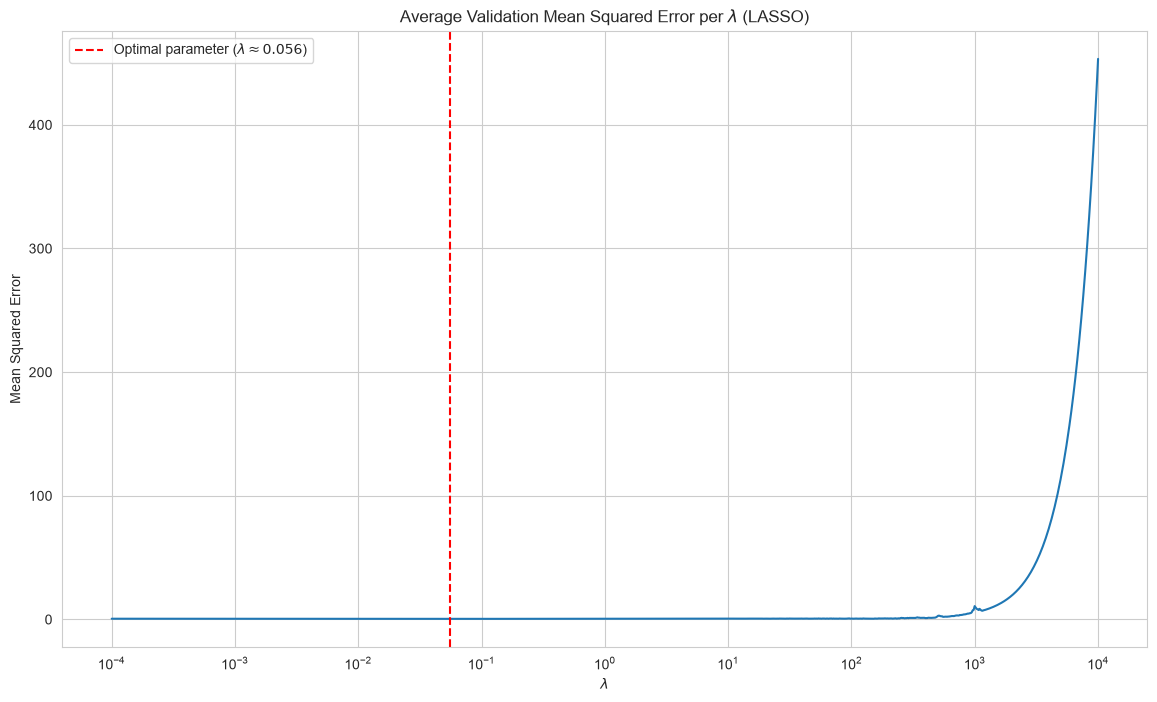

In [36]:
plt.figure(figsize=(14, 8))
plt.plot(lasso_lambdas, avg_val_mses_lasso)
plt.xscale("log")
plt.axvline(opt_lam_lasso, color="red", linestyle="--",
            label=fr"Optimal parameter ($\lambda \approx {opt_lam_lasso:.3f}$)")
plt.title(r"Average Validation Mean Squared Error per $\lambda$ (LASSO)")
plt.ylabel("Mean Squared Error")
plt.xlabel(r"$\lambda$")
plt.legend()
plt.show()


Now that we have the optimal $\lambda$, we will again compute the mean squared error on the test set.

In [37]:
theta_opt_lam = gradient_descent(X_train_aug, y_train, opt_lam_lasso)
y_hat_lasso_train = X_train_aug @ theta_opt_lam
y_hat_lasso_test = X_test_aug @ theta_opt_lam


lasso_train_mse = mse(y_hat_lasso_train.ravel(), y_train)
lasso_test_mse = mse(y_hat_lasso_test.ravel(), y_test)

print("Mean squared errors on train and test set for LASSO regression")
print("-"*70)
print(f"Train set: {lasso_train_mse}")
print(f"Test set: {lasso_test_mse}")

Reached max iterations.
Mean squared errors on train and test set for LASSO regression
----------------------------------------------------------------------
Train set: 0.3498904604017187
Test set: 0.45203216605649793


## 5. Discussion

In this notebook, we have ran least squares, ridge and LASSO regression to predict Djokovic's odds using our chosen features. We have used cross-validation to find the optimal hyperparameters for ridge and LASSO, and then evaluated train and test mean squared errors for all models.

Our original thought for introducing ridge and LASSO was that there is some collinearity present in our data, which can inflate coefficient variances, and can lead to coefficients of very large magnitudes. Large coefficient variance leads to high variance in our model predictions. Since the mean squared error decomposes into a squared bias and variance term, this can negatively affect the mean squared error of our model. Ridge and LASSO add in some bias in return for decreasing the variance of the parameter estimates, which decreases the variance of the predictions themselves. If the decrease in the variance outweighs the increase in squared bias, then these regularisation techniques can lead to better-performing models, and can better handle the instability introduced by colinearity.

The best-performing model was the ridge regression, which achieved a test mean squared error of $0.33$, compared to $0.44$ for least squares (OLS), and $0.45$ for LASSO. This indicates that the variance decrease introduced by parameter shrinkage has effectively decreased the overall mean squared error. Since LASSO performs worse, this indicates that the more aggressive shrinkage of LASSO

| Model | Train MSE | Test MSE |
|-------|-----------|----------|
| OLS   | 0.34      | 0.44     |
| Ridge | 0.35      | 0.33     |
| LASSO | 0.35      | 0.45     |